# 📊 Phân Tích Dữ Liệu Normalized (V2 - Đã Cải Thiện)

Notebook này được tạo ra để trực quan hóa dữ liệu **sau khi đã xử lý các vấn đề nghiêm trọng** phát hiện ở phiên bản đầu phân tích đầu.

**Các cải tiến chính đã thực hiện tại vòng 2:**
1. Áp dụng `CLIP_LOG_ROBUST` (Clip p99.5 + log1p + RobustScaler) cho các feature có phân phối heavy-tailed (`pm25`, `pm10`, `no2`).
2. Giới hạn lại Split Ratio (Train/Val/Test) thành `~68.5% / 11.3% / 20.2%` (bằng cách đổi `TRAIN_END` thành `2024-12-31`).
3. Dọn dẹp các tính năng dư thừa (xóa rủi ro Collinearity của `dpd` và `stagnation_index`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Cấu hình UI
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})
%matplotlib inline

# Load toàn bộ 16 dữ liệu stations đã normalized v2
NORMALIZED_DIR = 'data/normalized'
file_paths = glob.glob(f"{NORMALIZED_DIR}/norm_station_*.csv")

dfs = []
for path in file_paths:
    df = pd.read_csv(path, parse_dates=['timestamp'])
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(all_df):,}")
print(f"Total model input columns: {len(all_df.columns)}")

all_df.head(3)

Total rows loaded: 408,976
Total model input columns: 31


,timestamp,pm25,pm10,co,o3,no2,so2,temp,rh,dewpt,...,dust_source_potential,is_frozen,is_outlier,is_pm25_sensor_error,station_id,province,district,wind_sin,wind_cos,split
0,2023-01-01 00:00:00,0.492060,0.422228,-0.200411,0.278530,-0.714566,0.015996,-2.474490,0.743590,-2.086828,...,0.657555,0.0,0.0,0.0,1,Ha Noi,Cau Giay,-0.069756,0.997564,train
1,2023-01-01 01:00:00,0.700316,0.623719,-0.275056,0.284333,-1.111647,-0.025277,-2.565723,0.782051,-2.070320,...,0.656050,0.0,0.0,0.0,1,Ha Noi,Cau Giay,-0.275637,0.961262,train
2,2023-01-01 02:00:00,0.791744,0.712151,-0.284799,0.245648,-1.111647,-0.038233,-2.620462,0.807692,-2.086828,...,0.656050,0.0,0.0,0.0,1,Ha Noi,Cau Giay,-0.275637,0.961262,train


## 1. Kiểm tra Distribution (Histograms & KDE)
Mục tiêu là kiểm chứng xem độ lệch (skewness) của các khí siêu nặng `pm25`, `pm10`, và `no2` đã được ép về mức an toàn chưa (ước tính cũ là Skew > 7.00, giờ mức tối ưu phải < 1.5).

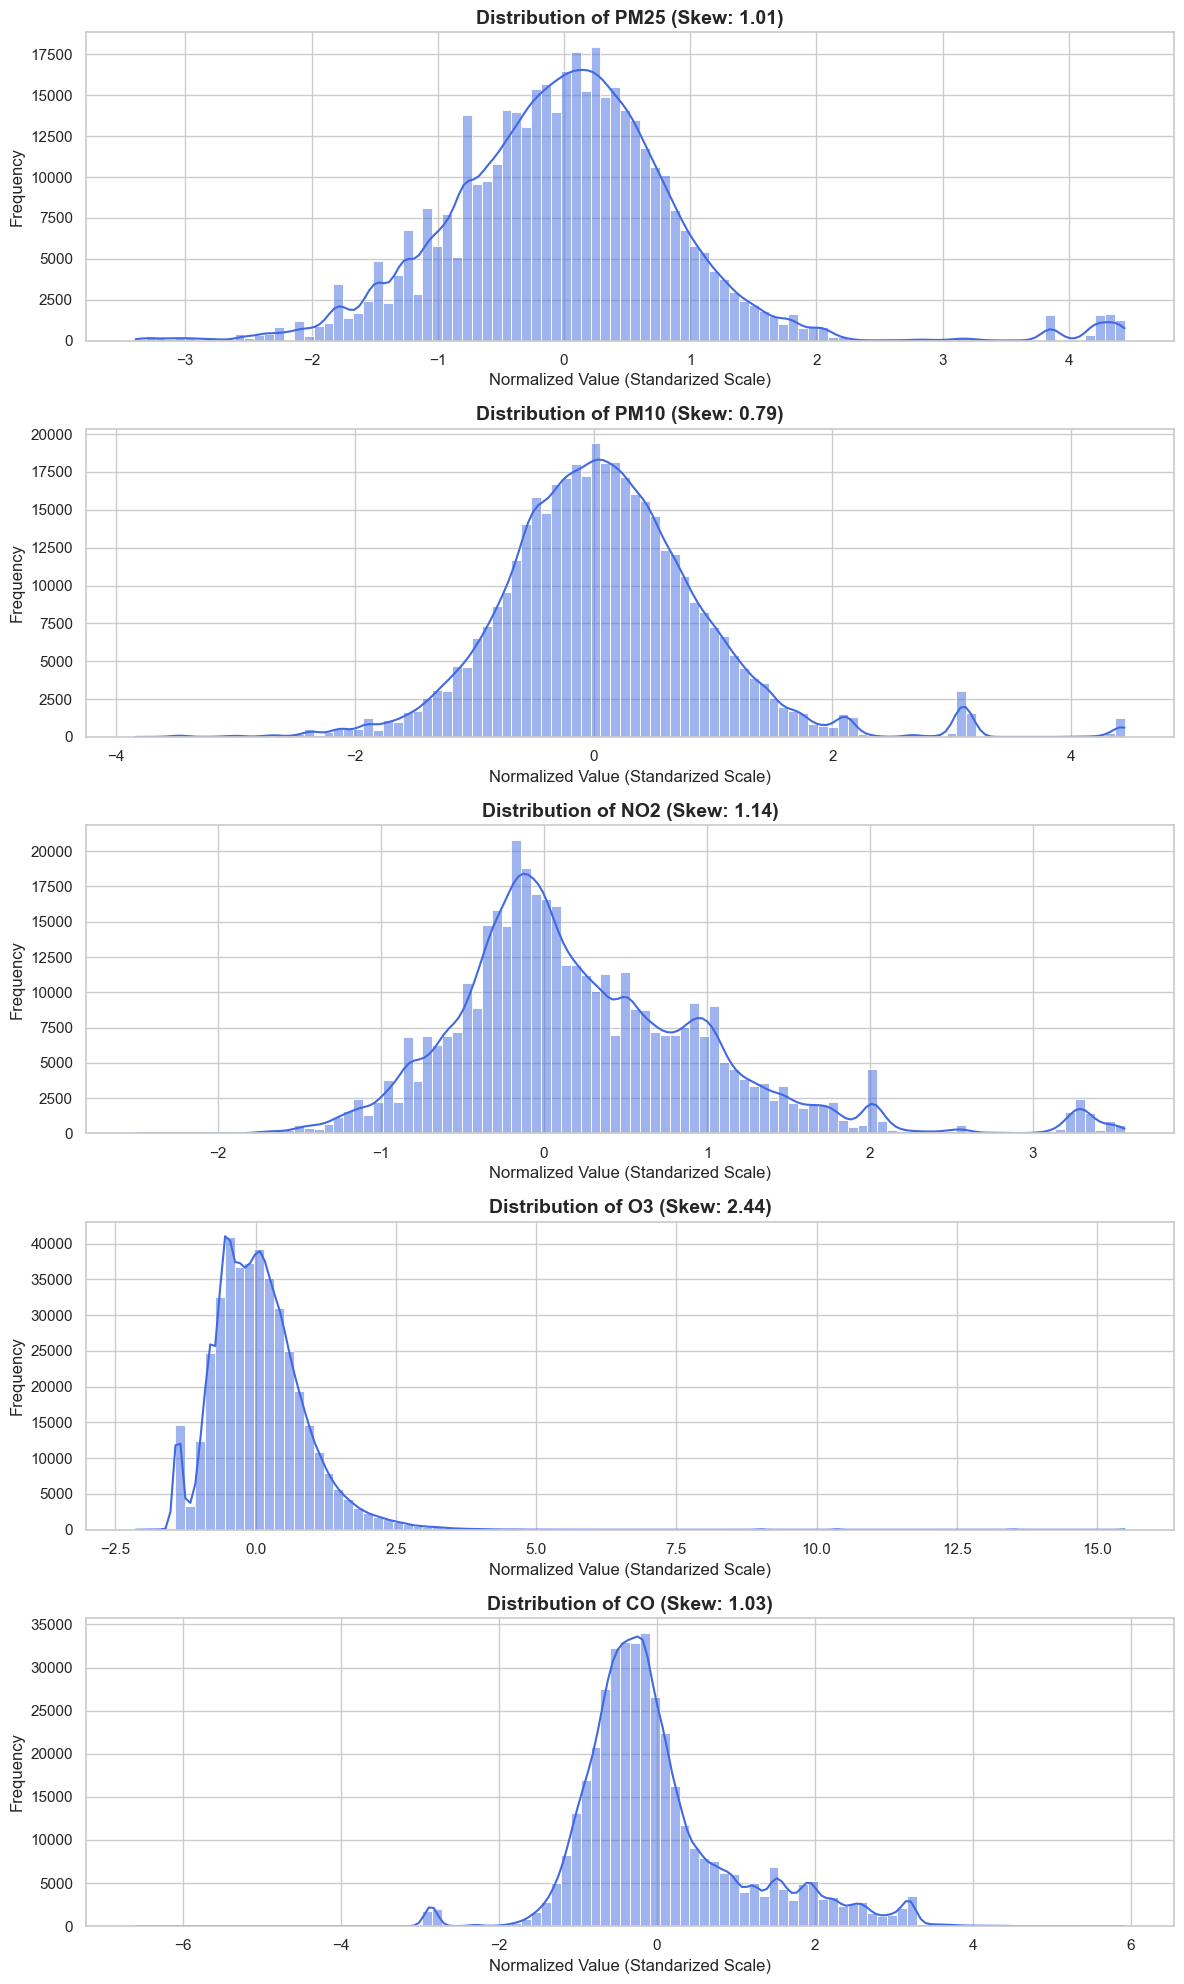

In [2]:
features_to_plot = ['pm25', 'pm10', 'no2', 'o3', 'co']

fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(12, 4 * len(features_to_plot)))

for i, col in enumerate(features_to_plot):
    if col in all_df.columns:
        sns.histplot(all_df[col].dropna(), bins=100, kde=True, ax=axes[i], color='royalblue')
        skew_val = all_df[col].skew()
        axes[i].set_title(f'Distribution of {col.upper()} (Skew: {skew_val:.2f})', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Normalized Value (Standarized Scale)')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 2. Kiểm tra Outliers Error (Boxplots)
Xem xét Extreme Outliers (Max range). Lần trước `NO2` có Max dội lên tới 310.60. Bây giờ boxplot phải hiển thị scale nhỏ gọn hơn (nằm an toàn trong khoảng `±5sigma`).

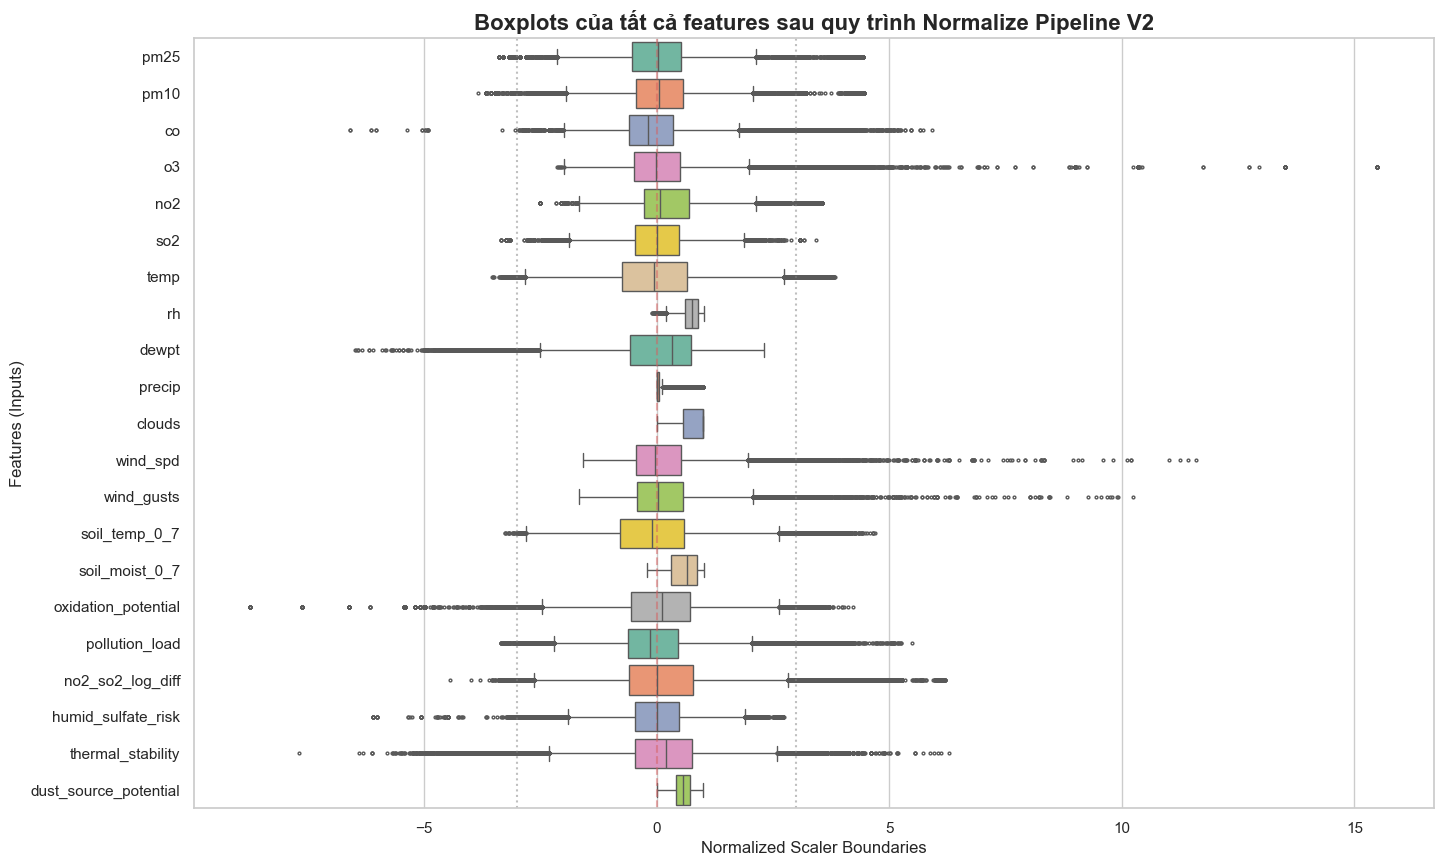

In [3]:
# Bỏ qua các cột metadata và sin/cos
numeric_cols = [c for c in all_df.columns if c not in ['station_id', 'timestamp', 'province', 'district', 'split', 'is_frozen', 'is_outlier', 'is_pm25_sensor_error', 'wind_sin', 'wind_cos']]

plt.figure(figsize=(16, 10))
sns.boxplot(data=all_df[numeric_cols], orient='h', fliersize=2, palette='Set2')
plt.title('Boxplots của tất cả features sau quy trình Normalize Pipeline V2', fontsize=16, fontweight='bold')
plt.xlabel('Normalized Scaler Boundaries')
plt.ylabel('Features (Inputs)')
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.axvline(3, color='grey', linestyle=':', alpha=0.5)
plt.axvline(-3, color='grey', linestyle=':', alpha=0.5)
plt.show()

## 3. Bản đồ Tương Quan (Correlation Heatmap)
Đảm bảo các cặp feature có độ tương quan `r > 0.9` đã được làm sạch phần lớn (đã xóa triệt để `dpd` và `stagnation_index`).

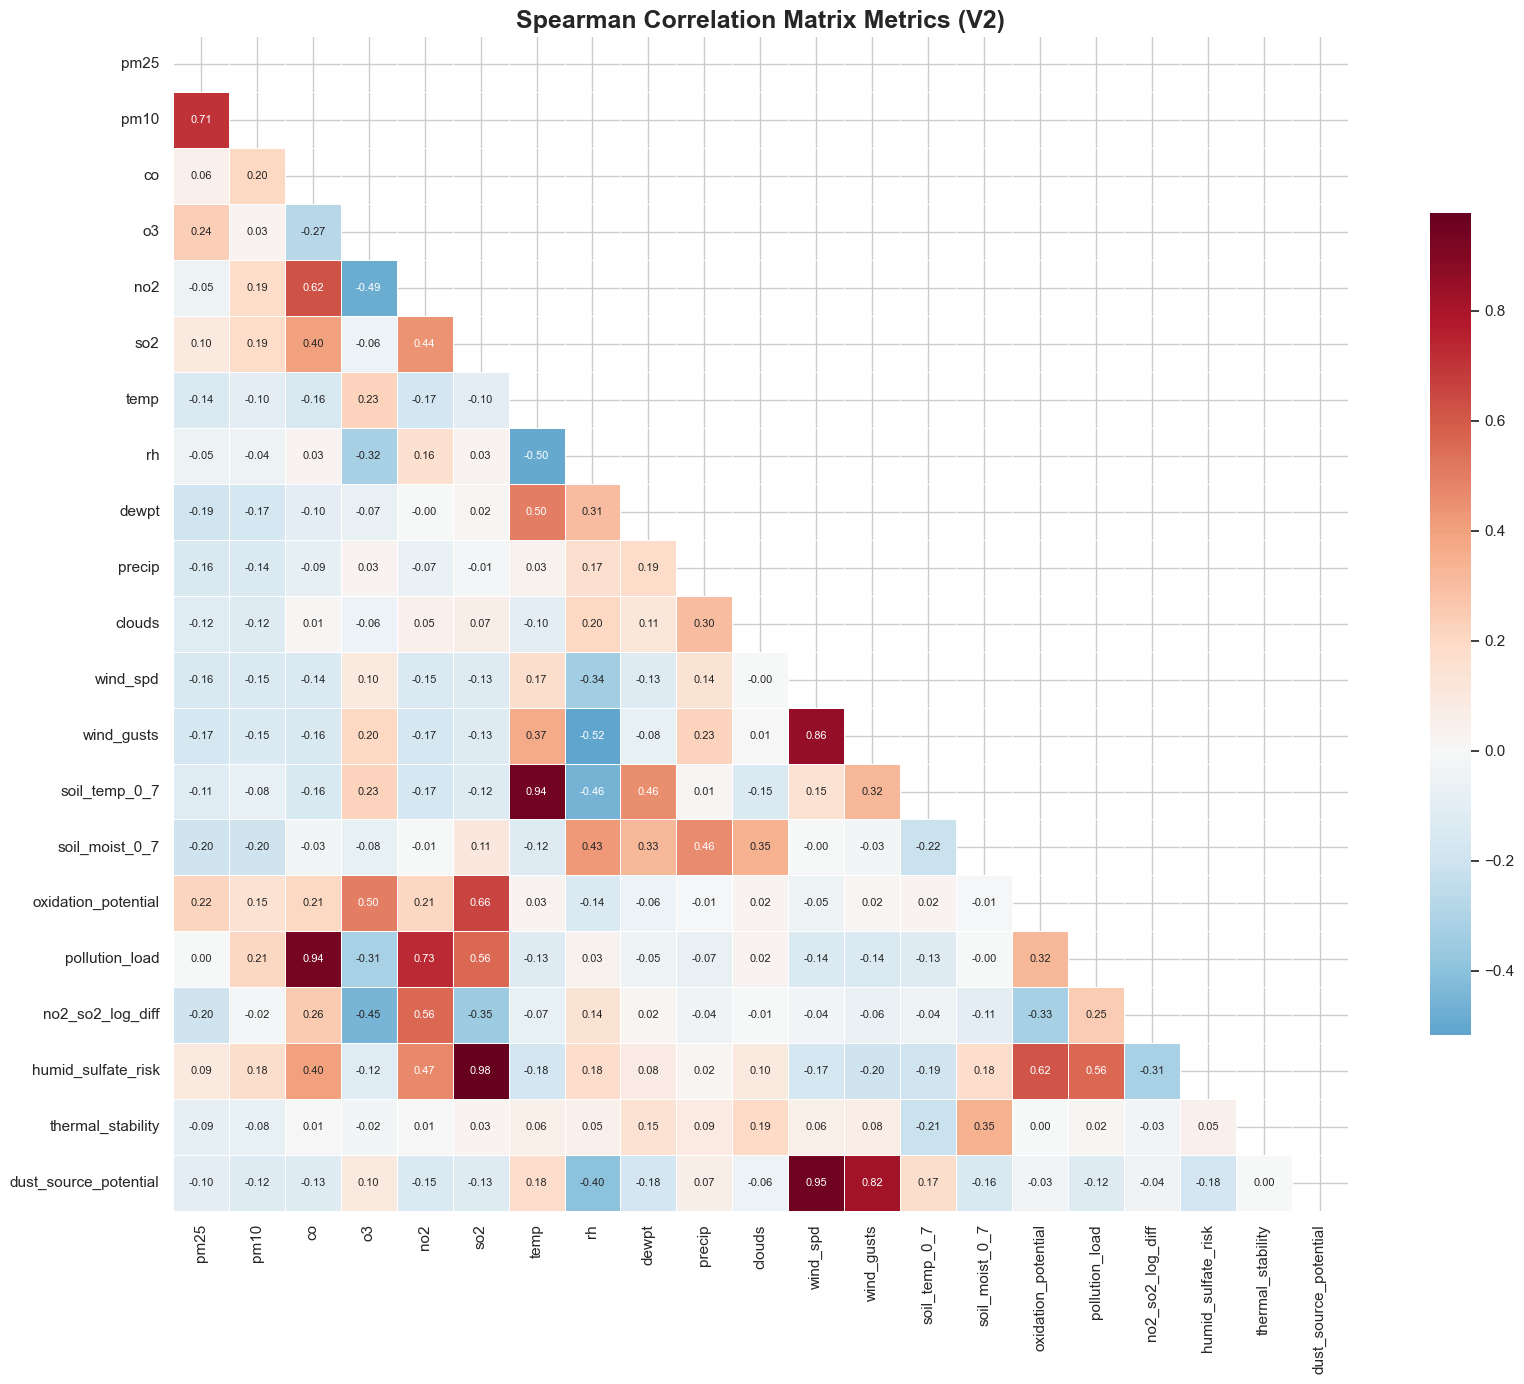

In [4]:
# Lấy sample random 50k mẫu để render Correlation Heatmap nhẹ và nhanh hơn
sample_df = all_df[numeric_cols].sample(min(50000, len(all_df)), random_state=42)
corr_matrix = sample_df.corr(method='spearman')

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            annot=True, fmt='.2f', square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot_kws={'size': 8})
plt.title('Spearman Correlation Matrix Metrics (V2)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Kiểm tra Chuỗi Thời Gian Chronological Split
Trực quan hóa một trạm ngẫu nhiên (VD: Trạm Biên Hòa - Id: 24 vì nhiều KCN khói bụi) để xem lượng Data Split cho mô hình Train/Val/Test.

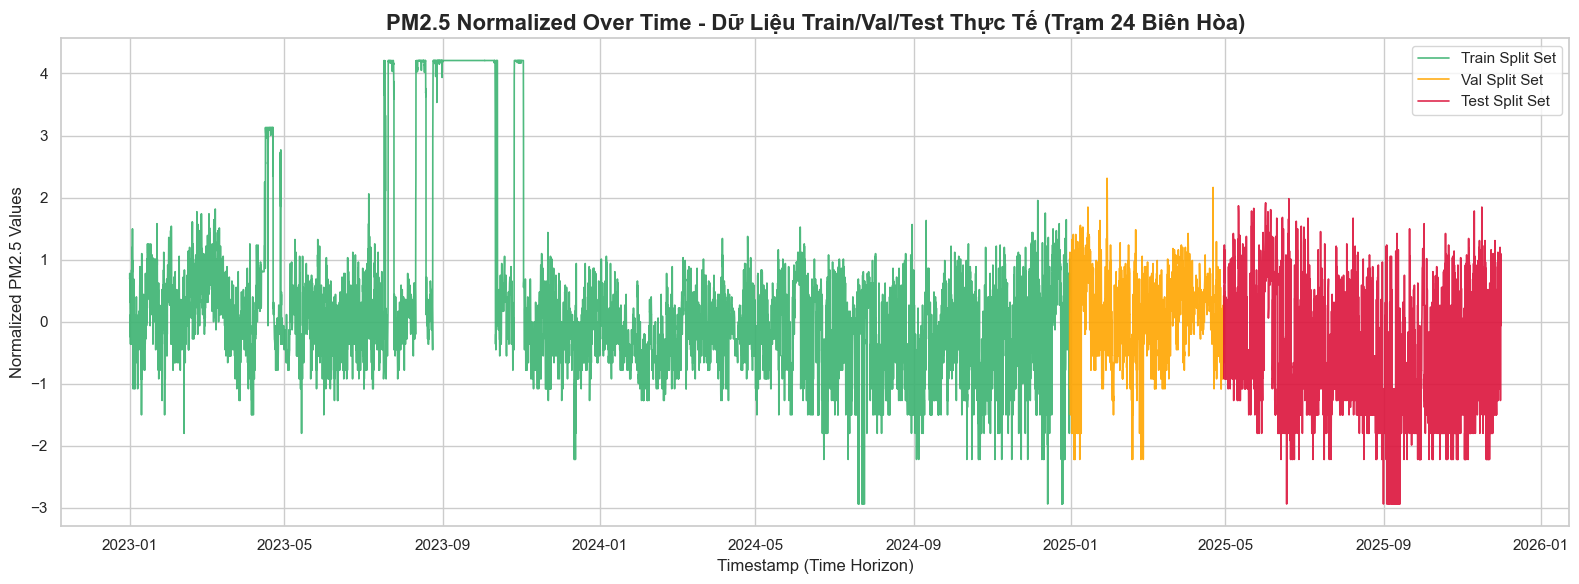

In [5]:
station_df = all_df[all_df['station_id'] == 24].set_index('timestamp').sort_index()

plt.figure(figsize=(16, 6))
colors = {'train': 'mediumseagreen', 'val': 'orange', 'test': 'crimson'}

for split_type in ['train', 'val', 'test']:
    mask = station_df['split'] == split_type
    plt.plot(station_df.index[mask], station_df.loc[mask, 'pm25'], 
             label=f'{split_type.capitalize()} Split Set', color=colors[split_type], linewidth=1.2, alpha=0.9)

plt.title('PM2.5 Normalized Over Time - Dữ Liệu Train/Val/Test Thực Tế (Trạm 24 Biên Hòa)', fontsize=16, fontweight='bold')
plt.xlabel('Timestamp (Time Horizon)')
plt.ylabel('Normalized PM2.5 Values')
plt.legend()
plt.tight_layout()
plt.show()